In [5]:
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
from tqdm import tqdm
import numpy as np

# 1. โหลดข้อมูล
df = pd.read_csv('data/cleaned_features.csv')
X = df.drop(columns=['Target_Dangerous'])
if 'AnimalName' in X.columns: X = X.drop(columns=['AnimalName'])
y = df['Target_Dangerous']

# 2. แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data Loaded: {X_train.shape[0]} samples for training, {X_test.shape[0]} for testing.")

Training Progress:   0%|          | 0/100 [05:45<?, ?it/s]


Data Loaded: 671 samples for training, 168 for testing.


In [6]:
# ตั้งค่า Folder
model_path = 'models/randomforest'
if not os.path.exists(model_path): os.makedirs(model_path)

# เทรนแบบ Warm Start เพื่อดึงค่า Accuracy ระหว่างทาง
n_trees = 100
model = RandomForestClassifier(n_estimators=1, warm_start=True, random_state=42, class_weight='balanced')

train_scores = []
test_scores = []

print("🚀 Training Random Forest...")
for i in tqdm(range(1, n_trees + 1)):
    model.n_estimators = i
    model.fit(X_train, y_train)
    
    # เก็บค่าไปพลอต Graph 1
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

# บันทึกโมเดล
joblib.dump(model, f'{model_path}/animal_risk_model.pkl')
joblib.dump(X.columns.tolist(), f'{model_path}/feature_columns.pkl')
print(f"✅ Model saved to {model_path}")

🚀 Training Random Forest...


  0%|          | 0/100 [00:00<?, ?it/s]e:\KU\KU3-2\ML\Project\Danger\.venv\lib\site-packages\sklearn\ensemble\_forest.py:860: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
e:\KU\KU3-2\ML\Project\Danger\.venv\lib\site-packages\sklearn\ensemble\_forest.py:860: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate th

✅ Model saved to models/randomforest


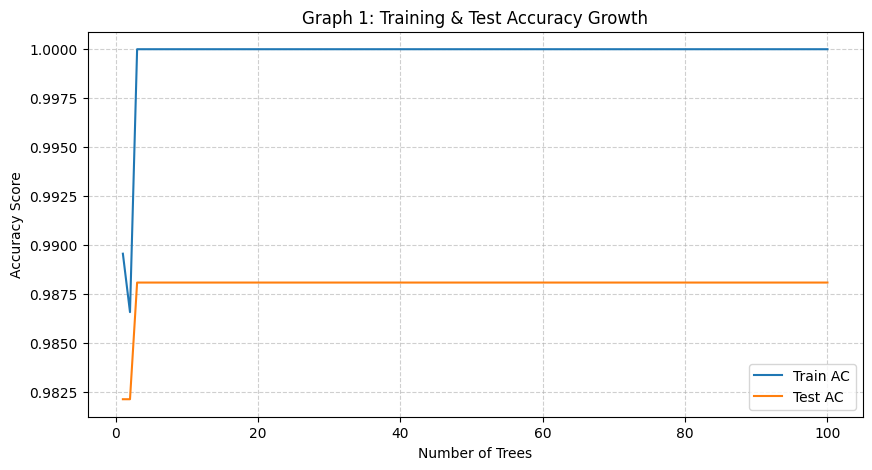

C:\Users\user\AppData\Local\Temp\ipykernel_9148\903330653.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')


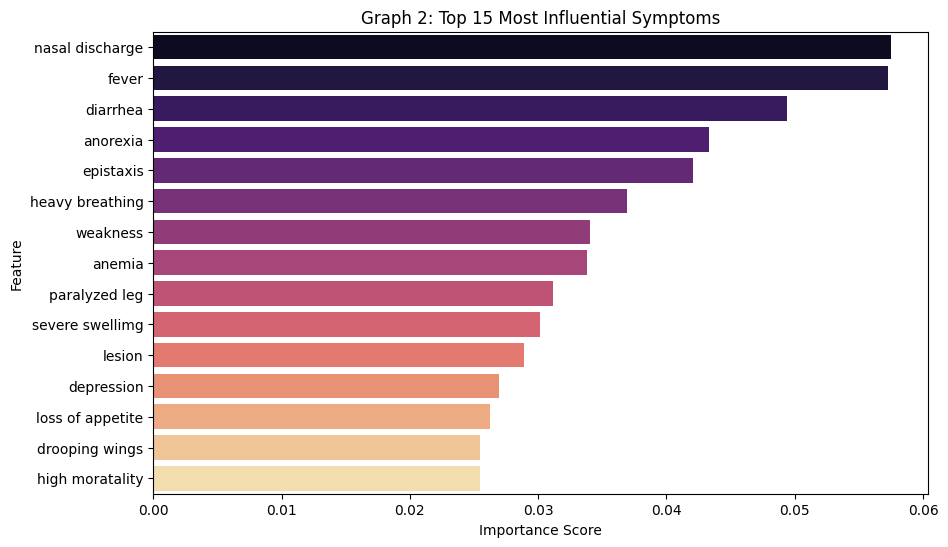

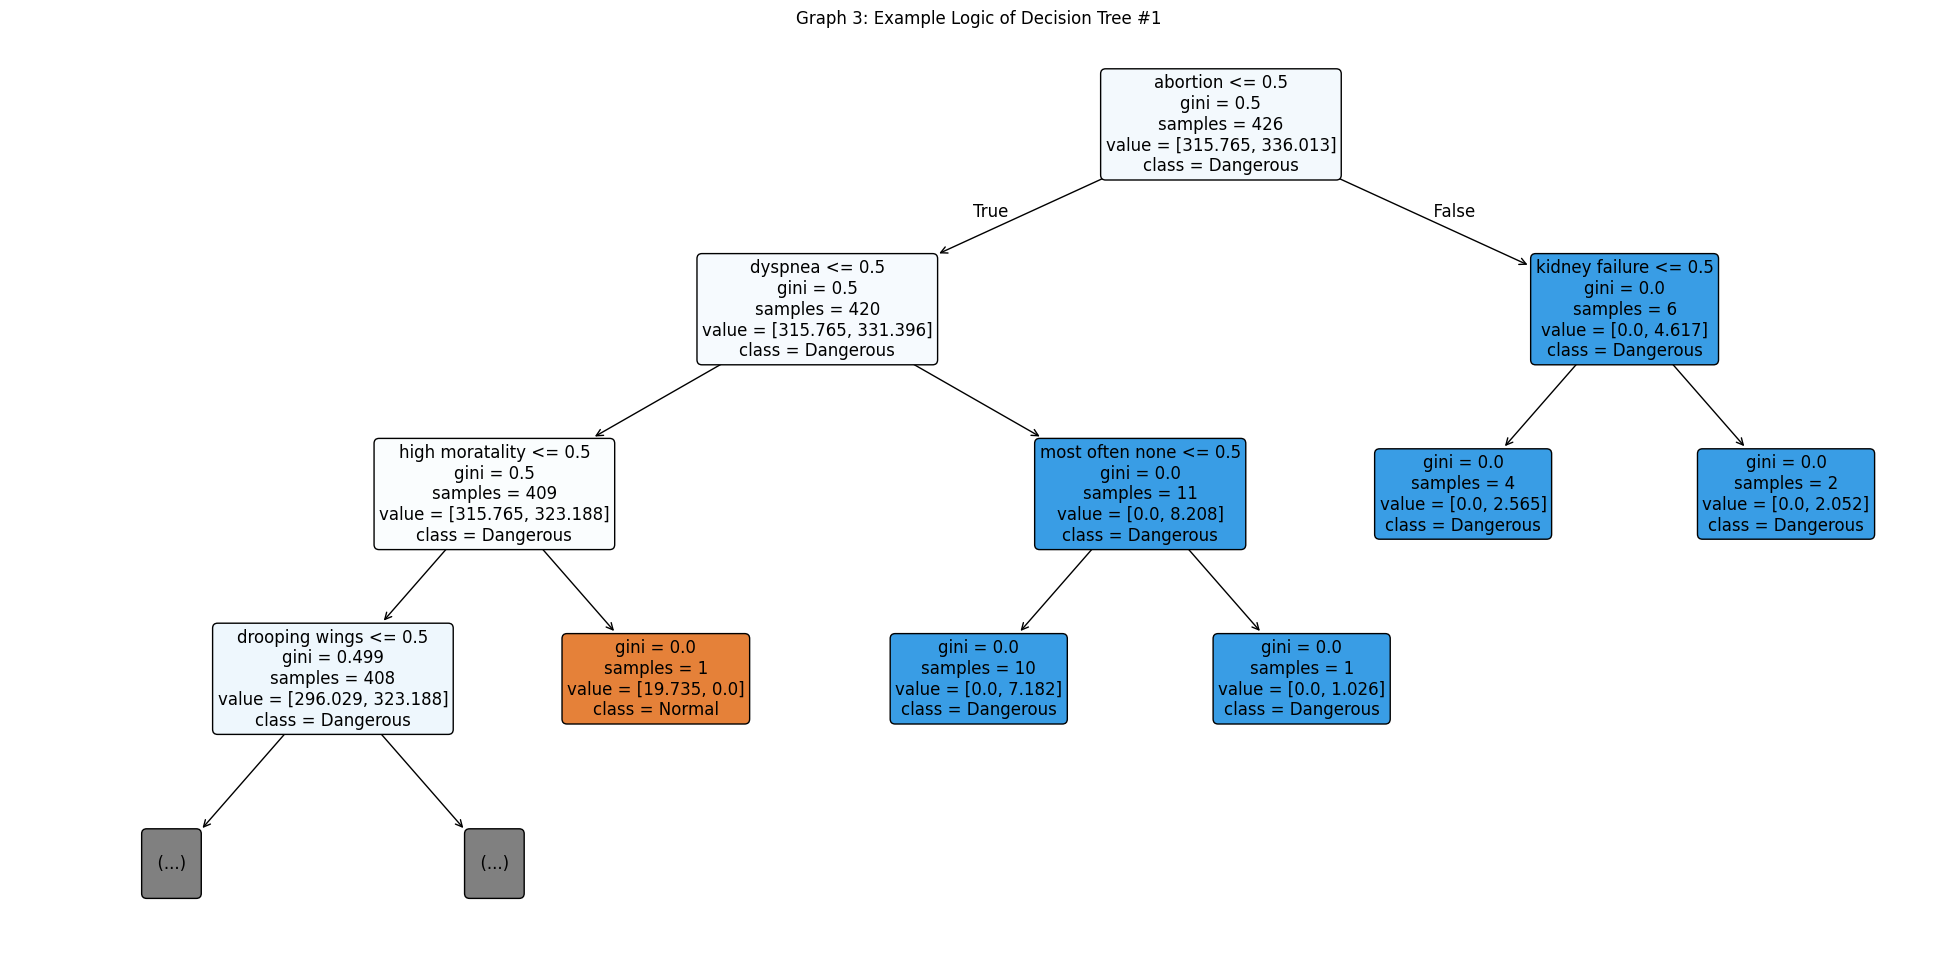

In [7]:
# --- Graph 1: Training Graph (Learning Curve) ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_trees + 1), train_scores, label='Train AC', color='#1f77b4')
plt.plot(range(1, n_trees + 1), test_scores, label='Test AC', color='#ff7f0e')
plt.title('Graph 1: Training & Test Accuracy Growth')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Graph 2: Feature Importance (Explainable AI) ---
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')
plt.title('Graph 2: Top 15 Most Influential Symptoms')
plt.xlabel('Importance Score')
plt.show()

# --- Graph 3: Decision Tree Visual (Logic Structure) ---
plt.figure(figsize=(25, 12))
tree.plot_tree(model.estimators_[0], 
               feature_names=X.columns,  
               class_names=['Normal', 'Dangerous'],
               filled=True, 
               max_depth=3, # ดูแค่ 3 ชั้นแรกเพื่อความชัดเจน
               fontsize=12,
               rounded=True)
plt.title('Graph 3: Example Logic of Decision Tree #1')
plt.show()

📊 Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.99      1.00      0.99       165

    accuracy                           0.99       168
   macro avg       0.99      0.67      0.75       168
weighted avg       0.99      0.99      0.99       168



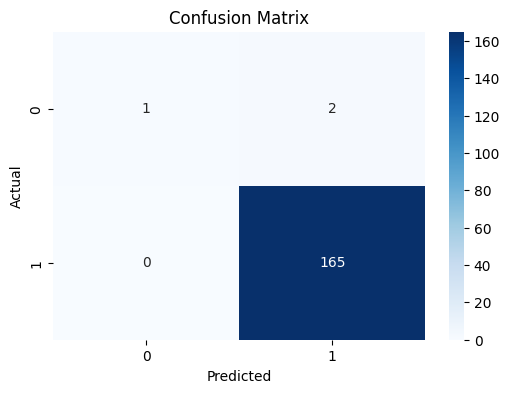

In [8]:
y_pred = model.predict(X_test)
print("📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()